# Title

Angos and Tan

BSDSBA 2028

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

### Data Download

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("usdot/flight-delays", output_dir="./data")

# print("Path to dataset files:", path)

c:\Users\Bob\anaconda3\envs\data-science\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 191M/191M [13:34<00:00, 246kB/s] 

Extracting files...


Path to dataset files: ./data


# OVERVIEW

This mini-project analyzes airline operations using the **U.S. Department of Transportation (DOT) 2015 Flight Delays and Cancellations dataset**. The project investigates how airport congestion, airline scheduling practices, and traffic density contribute to flight delays. In addition to identifying structural causes of delays, the project aims to forecast flight delay duration based on operational conditions, including airport traffic, route characteristics, and schedule realism.

Airline delays are often attributed to weather or operational disruptions, but underlying causes may include unrealistic scheduling and airport capacity constraints. By analyzing patterns in flight schedules, traffic density, and delay distributions, this project aims to identify systemic patterns that contribute to delays and congestion.

Understanding these factors has practical applications for airlines, airports, and passengers. Airlines can improve schedule planning, airports can identify congestion thresholds, and travelers can better understand which routes or airports are more reliable.


## GOALS

1. Analyze patterns in flight delays across airlines, routes, airports, and time of day.

2. Identify congestion thresholds at which airport traffic density results in significant increases in delay.

3. Forecast expected delay duration for flights using operational features such as airport traffic, route reliability, and schedule realism.

4. Evaluate whether airline schedules are realistic by comparing scheduled flight time with actual flight durations.


## Basic

TODO:
- 
- See whether delays affect a planes next flight

## General Data Exploration

In [3]:
# Load Data
airlines = pd.read_csv("data/airlines.csv")
airports = pd.read_csv("data/airports.csv")
flights = pd.read_csv("data/flights.csv", low_memory=False)


In [ ]:
display(flights.head())
print(flights.info())
print(flights.shape)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DEPARTURE_HOUR
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,23.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 32 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

### Flights Composition:

In [4]:
cancelled_flights = (
    (flights.iloc[:, flights.columns.get_loc('CANCELLED')] == 1).sum()
    / len(flights))

diverted_flights = (
    (flights.iloc[:, flights.columns.get_loc('DIVERTED')] == 1).sum()
    / len(flights))

success_flights = 1 - cancelled_flights + diverted_flights

In [ ]:
success_flights_df = flights.loc[
    (
        (flights.iloc[:, flights.columns.get_loc("DIVERTED")].astype(int) == 0)
        & (flights.iloc[:, flights.columns.get_loc("CANCELLED")].astype(int) == 0)
    )
]

len_success_flights = len(success_flights_df)

In [ ]:
d_delay_flights = (
    success_flights_df.iloc[:, 
    success_flights_df.columns.get_loc('DEPARTURE_DELAY')] > 0
    ).sum() / len_success_flights

a_delay_flights = (
    success_flights_df.iloc[:, 
    success_flights_df.columns.get_loc('ARRIVAL_DELAY')] > 0
    ).sum() / len_success_flights

both_delay_flights = (
    (
        (success_flights_df['DEPARTURE_DELAY'] > 0)
        & (success_flights_df['ARRIVAL_DELAY'] > 0)
    ).sum()
) / len_success_flights

In [7]:
print(f"Cancelled flights: {cancelled_flights*100:.2f}%")
print(f"Diverted flights: {diverted_flights*100:.2f}%")
print(f"Successful flights: {success_flights*100:.2f}%")

Cancelled flights: 1.54%
Diverted flights: 0.26%
Successful flights: 98.72%


In [ ]:
print(f"Delayed Departures: {d_delay_flights*100:.2f}% of successful flights")
print(f"Delayed Arrivals: {a_delay_flights*100:.2f}% of successful flights")
print(f"Delayed Departures with delayed arrivals: {both_delay_flights*100:.2f}% of successful flights")


Delayed Departures: 37.02% of successful flights
Delayed Arrivals: 36.52% of successful flights
Delayed Departures with delayed arrivals: 26.39% of successful flights


### CLEANING DATA NEEDS
- Some airports are numbers instead of IATA codes, no reference table in dataset, unable to find elsewhere

Solution: temporarily ignore all october data

- Add Departure Hour

In [7]:
flights["DEPARTURE_HOUR"] = flights["DEPARTURE_TIME"] // 100

In [13]:
flights[flights['MONTH'] == 10][[
    'MONTH',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT']].tail()

,MONTH,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4871872,10,11292,12478
4871873,10,12478,10732
4871874,10,12478,14843
4871875,10,14747,12266
4871876,10,12892,12266


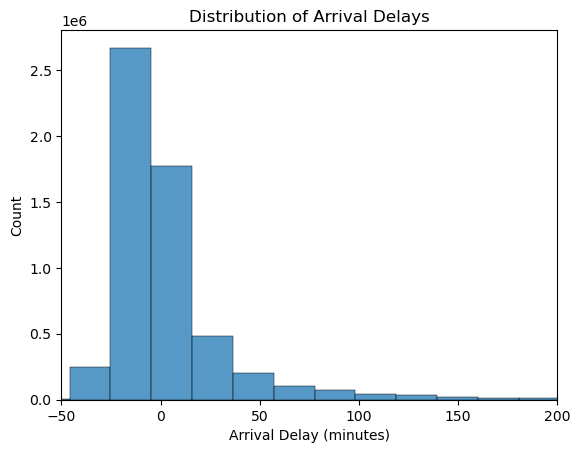

In [ ]:
sns.histplot(flights["ARRIVAL_DELAY"], bins=100)
plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

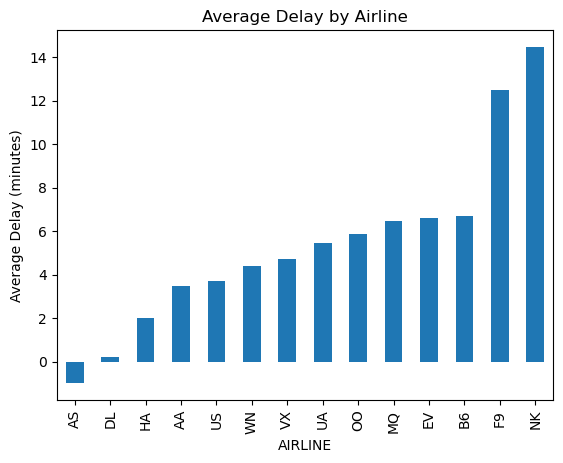

In [35]:
delay_by_airline = flights.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values()

delay_by_airline.plot(kind="bar")
plt.title("Average Delay by Airline")
plt.ylabel("Average Delay (minutes)")
plt.show()

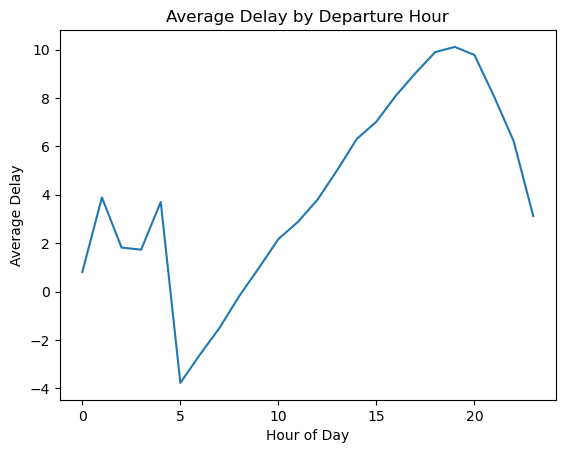

In [37]:
flights["DepHour"] = flights["SCHEDULED_DEPARTURE"] // 100

delay_by_hour = flights.groupby("DepHour")["ARRIVAL_DELAY"].mean()

delay_by_hour.plot()
plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay")
plt.show()

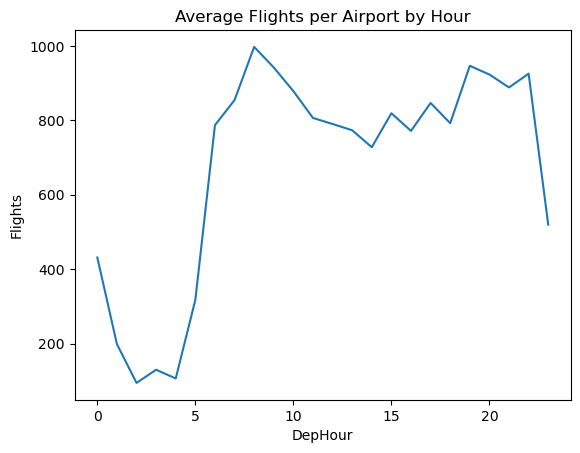

In [38]:
traffic = flights.groupby(["ORIGIN_AIRPORT","DepHour"]).size()

traffic_by_hour = traffic.groupby("DepHour").mean()

traffic_by_hour.plot()
plt.title("Average Flights per Airport by Hour")
plt.ylabel("Flights")
plt.show()

In [39]:
flights["on_time"] = flights["ARRIVAL_DELAY"] <= 10

route_reliability = (
    flights.groupby(["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"])["on_time"]
    .mean()
    .sort_values()
)

print(route_reliability.head(10))

ORIGIN_AIRPORT  DESTINATION_AIRPORT
MSN             BOS                    0.0
TYS             LEX                    0.0
IAD             DAY                    0.0
MDT             DEN                    0.0
RDU             PHF                    0.0
ORD             GJT                    0.0
11423           11433                  0.0
                13487                  0.0
12892           11884                  0.0
14843           12264                  0.0
Name: on_time, dtype: float64


In [10]:
sample = flights[((flights["MONTH"]==1)&(flights["DAY"]==1))]

In [11]:
valid_flights = flights[
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0)
]

route_df = (
    valid_flights
    .groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], as_index=False)
    .agg(AVE_FLIGHT_TIME=('ELAPSED_TIME', 'mean'))
)

In [13]:
route_df

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,AVE_FLIGHT_TIME
0,10135,10397,125.011364
1,10135,11433,99.786667
2,10135,13930,128.513158
3,10136,11298,53.463542
4,10140,10397,171.846154
...,...,...,...
8565,XNA,SFO,249.901961
8566,XNA,SLC,155.000000
8567,YAK,CDV,49.193846
8568,YAK,JNU,45.956923


In [ ]:
# Filter to only valid IATA codes (exclude numeric airport codes from October)
valid_flights = flights[
    flights["ORIGIN_AIRPORT"].str.match(r'^[A-Z]{3}$', na=False) &
    flights["DESTINATION_AIRPORT"].str.match(r'^[A-Z]{3}$', na=False)
].copy()

In [ ]:
# Build airport coordinate lookup
airport_coords = airports.set_index("IATA_CODE")[["LATITUDE", "LONGITUDE"]].to_dict("index")

In [ ]:
# Build frames for each departure hour
hours = sorted(valid_flights["DEPARTURE_HOUR"].unique())
frames = []
for hour in hours:
    hour_flights = valid_flights[valid_flights["DEPARTURE_HOUR"] == hour]
    edge_lats = []
    edge_lons = []
    for _, row in hour_flights.iterrows():
        orig, dest = row["ORIGIN_AIRPORT"], row["DESTINATION_AIRPORT"]
        if orig in airport_coords and dest in airport_coords:
            edge_lats += [airport_coords[orig]["LATITUDE"], airport_coords[dest]["LATITUDE"], None]
            edge_lons += [airport_coords[orig]["LONGITUDE"], airport_coords[dest]["LONGITUDE"], None]

    frames.append(go.Frame(
        data=[go.Scattermapbox(
            lat=edge_lats, lon=edge_lons,
            mode='lines',
            line=dict(width=1, color='red'),
            hoverinfo='none'
        )],
        name=str(int(hour))
    ))

In [ ]:
# Node trace for airports
used_airports = set(valid_flights["ORIGIN_AIRPORT"]) | set(valid_flights["DESTINATION_AIRPORT"])
used_airports = [a for a in used_airports if a in airport_coords]

node_trace = go.scattermap(
    lat=[airport_coords[a]["LATITUDE"] for a in used_airports],
    lon=[airport_coords[a]["LONGITUDE"] for a in used_airports],
    mode='markers',
    marker=dict(size=5, color='blue'),
    text=used_airports,
    hoverinfo='text'
)

fig = go.Figure(data=[node_trace], frames=frames)

fig.update_layout(
    mapbox=dict(style="open-street-map", center=dict(lat=39.8, lon=-98.5), zoom=3),
    margin=dict(l=0, r=0, t=30, b=0),
    title="Flight Routes by Departure Hour",
    updatemenus=[dict(
        type="buttons", showactive=False,
        buttons=[dict(
            label="Play", method="animate",
            args=[None, {"frame": {"duration": 1000, "redraw": True}, "fromcurrent": True}]
        )]
    )],
    sliders=[dict(
        steps=[
            dict(method="animate",
                 args=[[str(int(h))], {"frame": {"duration": 1000, "redraw": True}, "mode": "immediate"}],
                 label=str(int(h)))
            for h in hours
        ],
        currentvalue=dict(prefix="Hour: "),
    )]
)

fig.show()  # pyright: ignore[reportUnknownMemberType]

C:\Users\Sam\AppData\Local\Temp\ipykernel_14504\231743606.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 50), random_state=42))
C:\Users\Sam\AppData\Local\Temp\ipykernel_14504\231743606.py:37: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  data=[go.Scattermapbox(
C:\Users\Sam\AppData\Local\Temp\ipykernel_14504\231743606.py:37: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  data=[go.Scattermapbox(
C:\Users\Sam\AppData\Local\Temp\ipykernel_14504\231743606.py:50: DeprecationWarn

In [14]:
filtered_flights = flights[flights['CANCELLED'] == 0]

airports['avg_flights_per_hour'] = airports['IATA_CODE'].map(
    flights.assign(hour=filtered_flights['SCHEDULED_DEPARTURE']//100)
           .groupby(['ORIGIN_AIRPORT','hour'])
           .size()
           .groupby('ORIGIN_AIRPORT')
           .mean()
           .round()
)

In [15]:
airports

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,avg_flights_per_hour
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040,224.0
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190,159.0
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919,949.0
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183,74.0
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447,87.0
...,...,...,...,...,...,...,...,...
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48433,-132.36982,163.0
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.68840,-111.11764,52.0
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681,529.0
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023,328.0


In [16]:
valid_flights = flights[
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0)
]

route_df = (
    valid_flights
    .groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], as_index=False)
    .agg(AVE_FLIGHT_TIME=('ELAPSED_TIME', 'mean'))
)

## Intermediate

## Advanced